In [1]:
# ==============================================================================
# Script:           evaluate_betaVAE.py
# Purpose:          Post-training evaluation of BetaVAE latent space quality.
#                   Intended to be reformatted into a Jupyter notebook.
# Author:           Sophia Li
# Affiliation:      CCG Lab, Princess Margaret Cancer Center, UHN, UofT
# ==============================================================================

Sweep: betaVAE_sweep_20260302_214939
Best Trial: trial_18

Notes

# 0. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import torch
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import umap
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans

import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from MethylCDM.models.betaVAE import BetaVAE

/home/campbell/sophiali/miniforge3/envs/methylcdm-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Plotting defaults
plt.rcParams.update({
    "figure.dpi":    150,
    "font.size":     11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CHECKPOINT_PATH  = "/ddn_exa/campbell/sli/methylcdm-project/models/beta_vae/betaVAE_sweep_20260302_214939/trial_18/best-epoch=199-val_loss=5.7425.ckpt"
VAL_ADATA_PATH   = "/ddn_exa/campbell/sli/methylcdm-project/data/training/methylation/pancancer_val_adata.h5ad"
TEST_ADATA_PATH  = "/ddn_exa/campbell/sli/methylcdm-project/data/training/methylation/pancancer_test_adata.h5ad"

# 1. Load Model and Data

In [4]:
model = BetaVAE.load_from_checkpoint(CHECKPOINT_PATH, map_location=DEVICE)
model.eval()
model.to(DEVICE)

val_adata  = ad.read_h5ad(VAL_ADATA_PATH)
test_adata = ad.read_h5ad(TEST_ADATA_PATH)

In [5]:
def adata_to_tensor(adata):
    X = adata.X
    if sp.issparse(X):
        X = X.toarray()
    return torch.tensor(X, dtype=torch.float32).to(DEVICE)

X_val  = adata_to_tensor(val_adata)
X_test = adata_to_tensor(test_adata)

In [6]:
# Pull metadata — all samples are primary tumour so sample_type is not used
meta_val  = val_adata.obs.copy()
meta_test = test_adata.obs.copy()

# Derive short cancer type label from project_id (e.g. TCGA-LUAD → LUAD)
meta_val["cancer_type"]  = meta_val["project_id"].str.replace("TCGA-", "")
meta_test["cancer_type"] = meta_test["project_id"].str.replace("TCGA-", "")

print(f"Val shape:  {X_val.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Val cancer types ({meta_val['cancer_type'].nunique()}): "
      f"{sorted(meta_val['cancer_type'].unique())}")
print(f"\nModel: {CHECKPOINT_PATH}")
print(f"Latent dim: {model.hparams.latent_dim}")

Val shape:  torch.Size([304, 211580])
Test shape: torch.Size([380, 211580])
Val cancer types (10): ['CESC', 'CHOL', 'COAD', 'ESCA', 'GBM', 'KIRP', 'LUAD', 'OV', 'PAAD', 'UVM']

Model: /ddn_exa/campbell/sli/methylcdm-project/models/beta_vae/betaVAE_sweep_20260302_214939/trial_18/best-epoch=199-val_loss=5.7425.ckpt
Latent dim: 67


# Evaluating Raw Data Distribution

In [36]:
# Raw data M-value range
for adata, label in [
    (val_adata,   "val"),
    (test_adata,  "test"),
]:
    X = adata.X.data if sp.issparse(adata.X) else adata.X
    print(f"\n--- {label} ---")
    print(f"  Min:        {X.min():.4f}")
    print(f"  Max:        {X.max():.4f}")
    print(f"  Mean:       {X.mean():.4f}")
    print(f"  Std:        {X.std():.4f}")
    print(f"  1st pctile: {np.percentile(X, 1):.4f}")
    print(f"  99th pctile:{np.percentile(X, 99):.4f}")


--- val ---
  Min:        -26.6674
  Max:        31.6482
  Mean:       -0.4631
  Std:        7.2477
  1st pctile: -20.0170
  99th pctile:19.9052

--- test ---
  Min:        -26.6537
  Max:        35.1164
  Mean:       -0.7176
  Std:        7.2117
  1st pctile: -20.0262
  99th pctile:19.9027


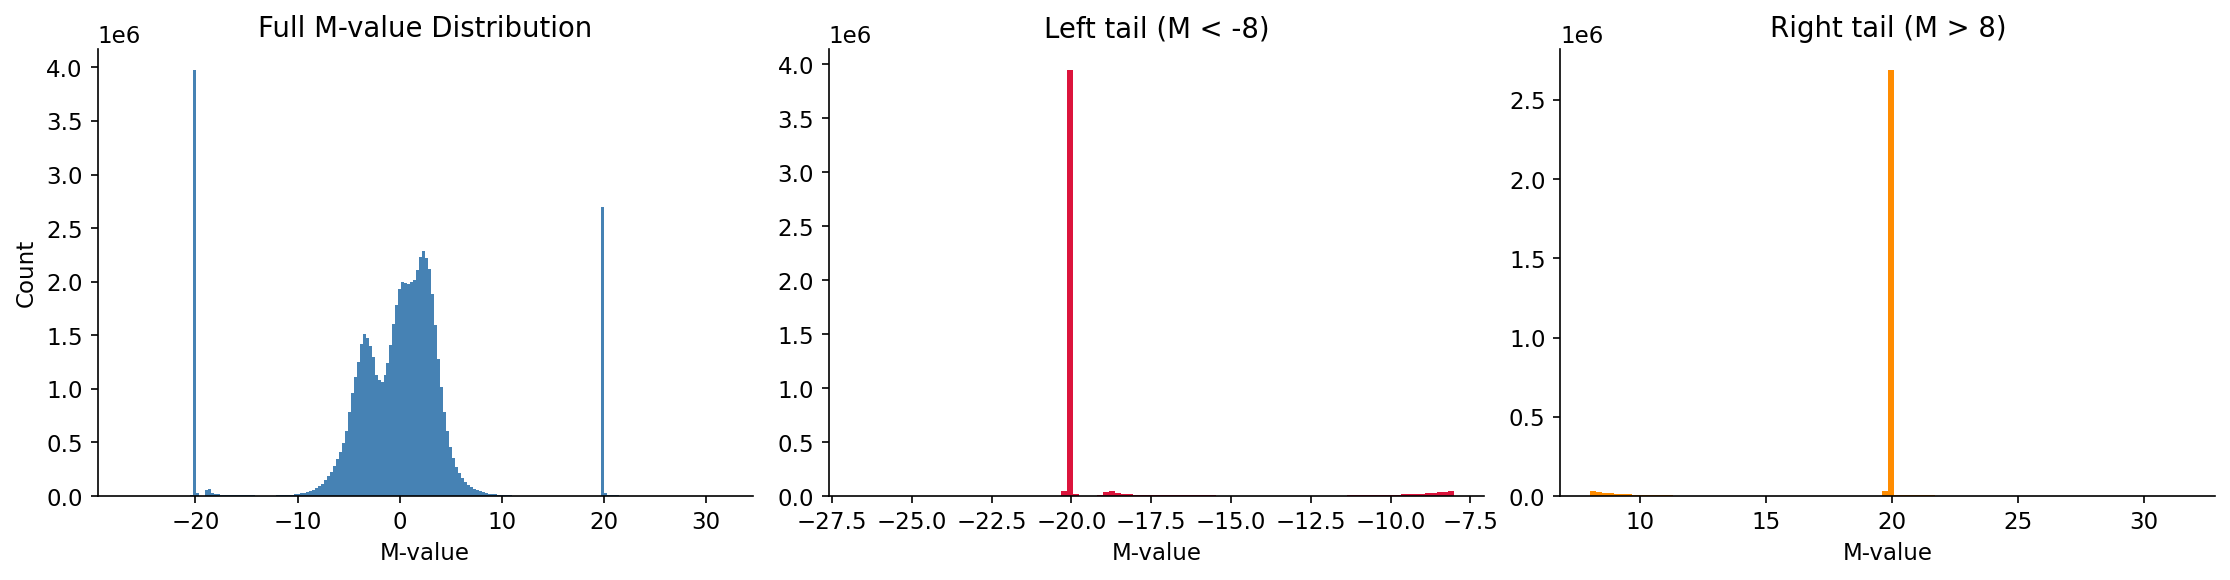

Values < -8:  4,700,060  (7.31%)
Values > 8:   3,010,773  (4.68%)
Values < -15: 4,295,896  (6.68%)
Values > 15:  2,806,111  (4.36%)


In [37]:
adata = val_adata
X = adata.X.data if sp.issparse(adata.X) else adata.X.flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full distribution
axes[0].hist(X, bins=200, color="steelblue", edgecolor="none")
axes[0].set_xlabel("M-value")
axes[0].set_ylabel("Count")
axes[0].set_title("Full M-value Distribution")

# Tail behaviour
axes[1].hist(X[X < -8],  bins=100, color="crimson", edgecolor="none")
axes[1].set_xlabel("M-value")
axes[1].set_title("Left tail (M < -8)")

axes[2].hist(X[X > 8], bins=100, color="darkorange", edgecolor="none")
axes[2].set_xlabel("M-value")
axes[2].set_title("Right tail (M > 8)")

plt.tight_layout()
plt.savefig("mvalue_distribution_diagnostic.png")
plt.show()

# Quantify tail sizes
print(f"Values < -8:  {(X < -8).sum():,}  ({100*(X < -8).mean():.2f}%)")
print(f"Values > 8:   {(X > 8).sum():,}  ({100*(X > 8).mean():.2f}%)")
print(f"Values < -15: {(X < -15).sum():,}  ({100*(X < -15).mean():.2f}%)")
print(f"Values > 15:  {(X > 15).sum():,}  ({100*(X > 15).mean():.2f}%)")

In [38]:
# Are extreme values concentrated in specific probes or spread across all probes?
X_dense = adata.X.toarray() if sp.issparse(adata.X) else adata.X

probe_max  = np.abs(X_dense).max(axis=0)   # max absolute M-value per probe
sample_max = np.abs(X_dense).max(axis=1)   # max absolute M-value per sample

print(f"Probes with max |M| > 15:  {(probe_max > 15).sum():,} / {len(probe_max):,}")
print(f"Samples with max |M| > 15: {(sample_max > 15).sum():,} / {len(sample_max):,}")

# If extreme values are concentrated in few probes, those are likely
# low-coverage or poorly performing probes that survived filtering

Probes with max |M| > 15:  189,412 / 211,580
Samples with max |M| > 15: 262 / 304


# 2. Extract Latent Embeddings

Use z_mu (posterior mean) not a reparameterised sample — z_mu is
deterministic and is the correct representation to hand to the downstream
diffusion model.

In [7]:
with torch.no_grad():
    z_mu_val,  z_logvar_val,  _ = model.encode(X_val)
    z_mu_test, z_logvar_test, _ = model.encode(X_test)
    x_hat_val  = model.decode(z_mu_val)
    x_hat_test = model.decode(z_mu_test)

z_mu_val      = z_mu_val.cpu().numpy()
z_mu_test     = z_mu_test.cpu().numpy()
z_logvar_val  = z_logvar_val.cpu().numpy()
z_logvar_test = z_logvar_test.cpu().numpy()
x_hat_val     = x_hat_val.cpu().numpy()
x_hat_test    = x_hat_test.cpu().numpy()
X_val_np      = X_val.cpu().numpy()
X_test_np     = X_test.cpu().numpy()

print(f"Embedding shape (val):  {z_mu_val.shape}")
print(f"Embedding shape (test): {z_mu_test.shape}")

Embedding shape (val):  (304, 67)
Embedding shape (test): (380, 67)


# 3. Reconstruction Quality

Per-sample Pearson r between true and reconstructed M-value vectors is the
primary metric. MSE is reported but less interpretable in absolute terms
because it scales with the variance of the input M-value distribution.

Additionally, check reconstruction quality broken down by project_id —
projects with fewer samples in the cohort may reconstruct worse, which
would indicate underrepresentation rather than model failure.

In [8]:
def reconstruction_metrics(X, X_hat, meta, label=""):
    mse_per_sample = np.mean((X - X_hat) ** 2, axis=1)
    r_per_sample   = np.array([
        np.corrcoef(X[i], X_hat[i])[0, 1] for i in range(X.shape[0])
    ])
    print(f"\n--- Reconstruction Metrics ({label}) ---")
    print(f"  MSE      — mean: {mse_per_sample.mean():.4f}  "
          f"std: {mse_per_sample.std():.4f}")
    print(f"  Pearson r — mean: {r_per_sample.mean():.4f}  "
          f"std: {r_per_sample.std():.4f}")
    print(f"  Pearson r < 0.9: "
          f"{(r_per_sample < 0.9).sum()} / {len(r_per_sample)} samples")

    # Per-project breakdown — flags underrepresented cancer types
    r_by_project = (
        pd.DataFrame({"cancer_type": meta["cancer_type"].values,
                      "pearson_r":   r_per_sample,
                      "mse":         mse_per_sample})
        .groupby("cancer_type")
        .agg(n=("pearson_r", "count"),
             r_mean=("pearson_r", "mean"),
             r_std=("pearson_r", "std"),
             mse_mean=("mse", "mean"))
        .sort_values("r_mean")
    )
    print(f"\n  Per-project reconstruction ({label}):")
    print(r_by_project.to_string())
    return mse_per_sample, r_per_sample, r_by_project

mse_val,  r_val,  r_by_proj_val  = reconstruction_metrics(
    X_val_np,  x_hat_val,  meta_val,  "Val"
)
mse_test, r_test, r_by_proj_test = reconstruction_metrics(
    X_test_np, x_hat_test, meta_test, "Test"
)


--- Reconstruction Metrics (Val) ---
  MSE      — mean: 5.7085  std: 4.9636
  Pearson r — mean: 0.9425  std: 0.0316
  Pearson r < 0.9: 33 / 304 samples

  Per-project reconstruction (Val):
              n    r_mean     r_std   mse_mean
cancer_type                                   
OV            1  0.855336       NaN   7.536937
CHOL          6  0.901702  0.062604  14.823361
CESC         46  0.928362  0.031742   7.681729
COAD         48  0.939257  0.025303   5.760481
LUAD         74  0.941427  0.035884   5.630585
ESCA         29  0.941434  0.027723   5.929513
GBM          21  0.941814  0.026789   6.112395
KIRP         40  0.954804  0.022842   4.442780
PAAD         27  0.961908  0.018119   2.262202
UVM          12  0.962148  0.012667   4.440316

--- Reconstruction Metrics (Test) ---
  MSE      — mean: 5.3804  std: 4.5152
  Pearson r — mean: 0.9448  std: 0.0295
  Pearson r < 0.9: 34 / 380 samples

  Per-project reconstruction (Test):
              n    r_mean     r_std   mse_mean
cancer_

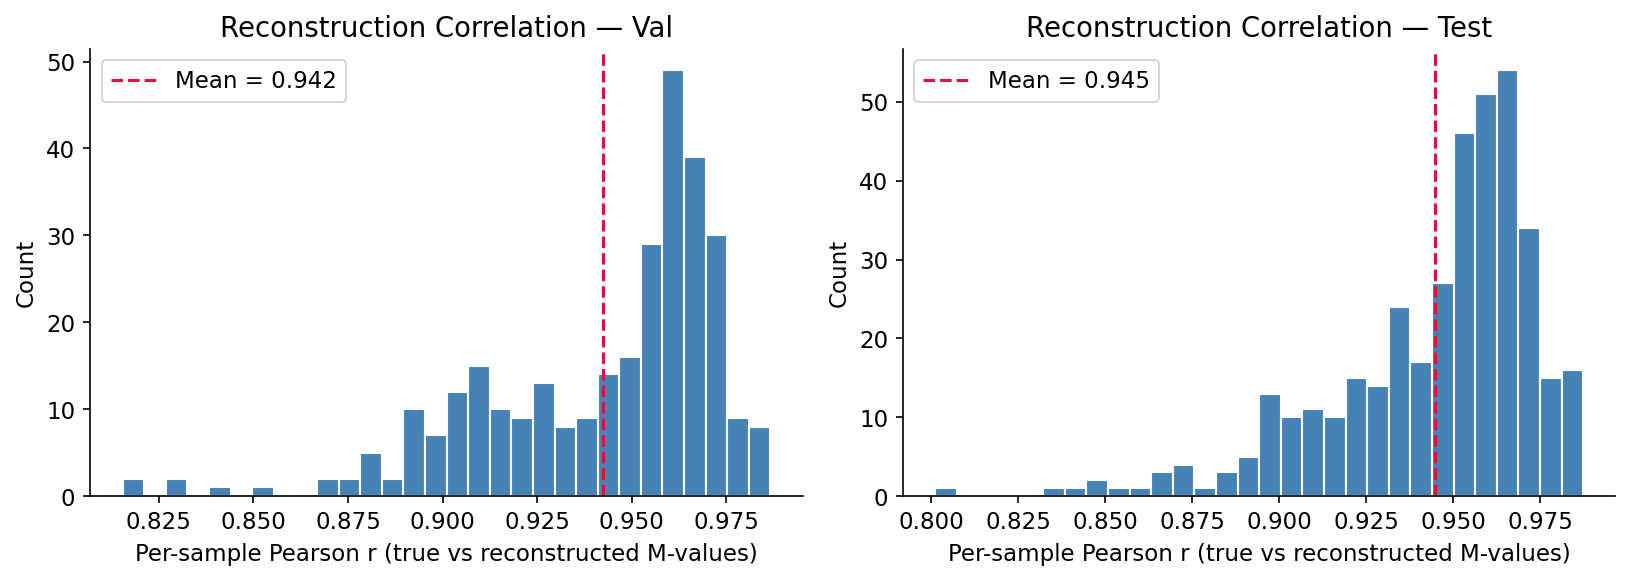

In [9]:
# Plot 1: Pearson r distribution (val vs test)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, r, label in zip(axes, [r_val, r_test], ["Val", "Test"]):
    ax.hist(r, bins=30, color="steelblue", edgecolor="white")
    ax.axvline(r.mean(), color="crimson", linestyle="--",
               label=f"Mean = {r.mean():.3f}")
    ax.set_xlabel("Per-sample Pearson r (true vs reconstructed M-values)")
    ax.set_ylabel("Count")
    ax.set_title(f"Reconstruction Correlation — {label}")
    ax.legend()
plt.tight_layout()
plt.savefig("eval_reconstruction_correlation.png")
plt.show()

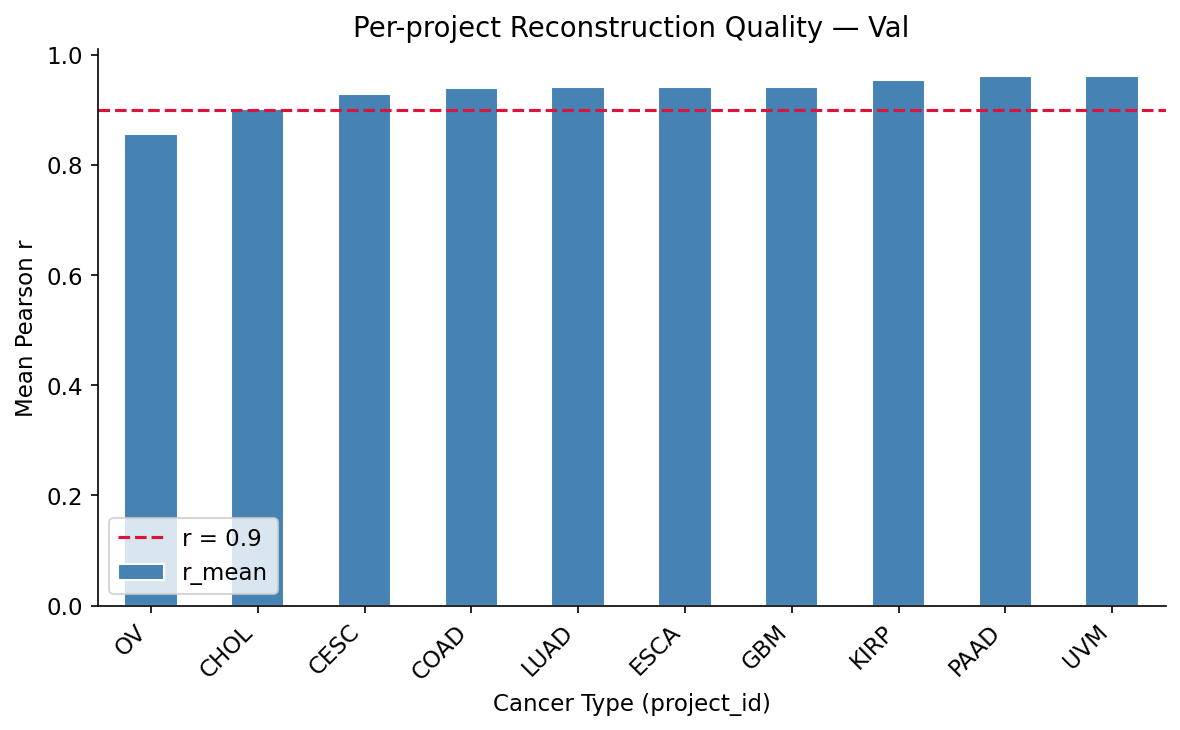

In [10]:
# Plot 2: Per-project mean Pearson r — sorted bar chart
fig, ax = plt.subplots(figsize=(max(8, len(r_by_proj_val) * 0.5), 5))
r_by_proj_val.sort_values("r_mean")["r_mean"].plot(
    kind="bar", ax=ax, color="steelblue", edgecolor="white"
)
ax.axhline(0.9, color="crimson", linestyle="--", label="r = 0.9")
ax.set_xlabel("Cancer Type (project_id)")
ax.set_ylabel("Mean Pearson r")
ax.set_title("Per-project Reconstruction Quality — Val")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig("eval_reconstruction_per_project.png")
plt.show()


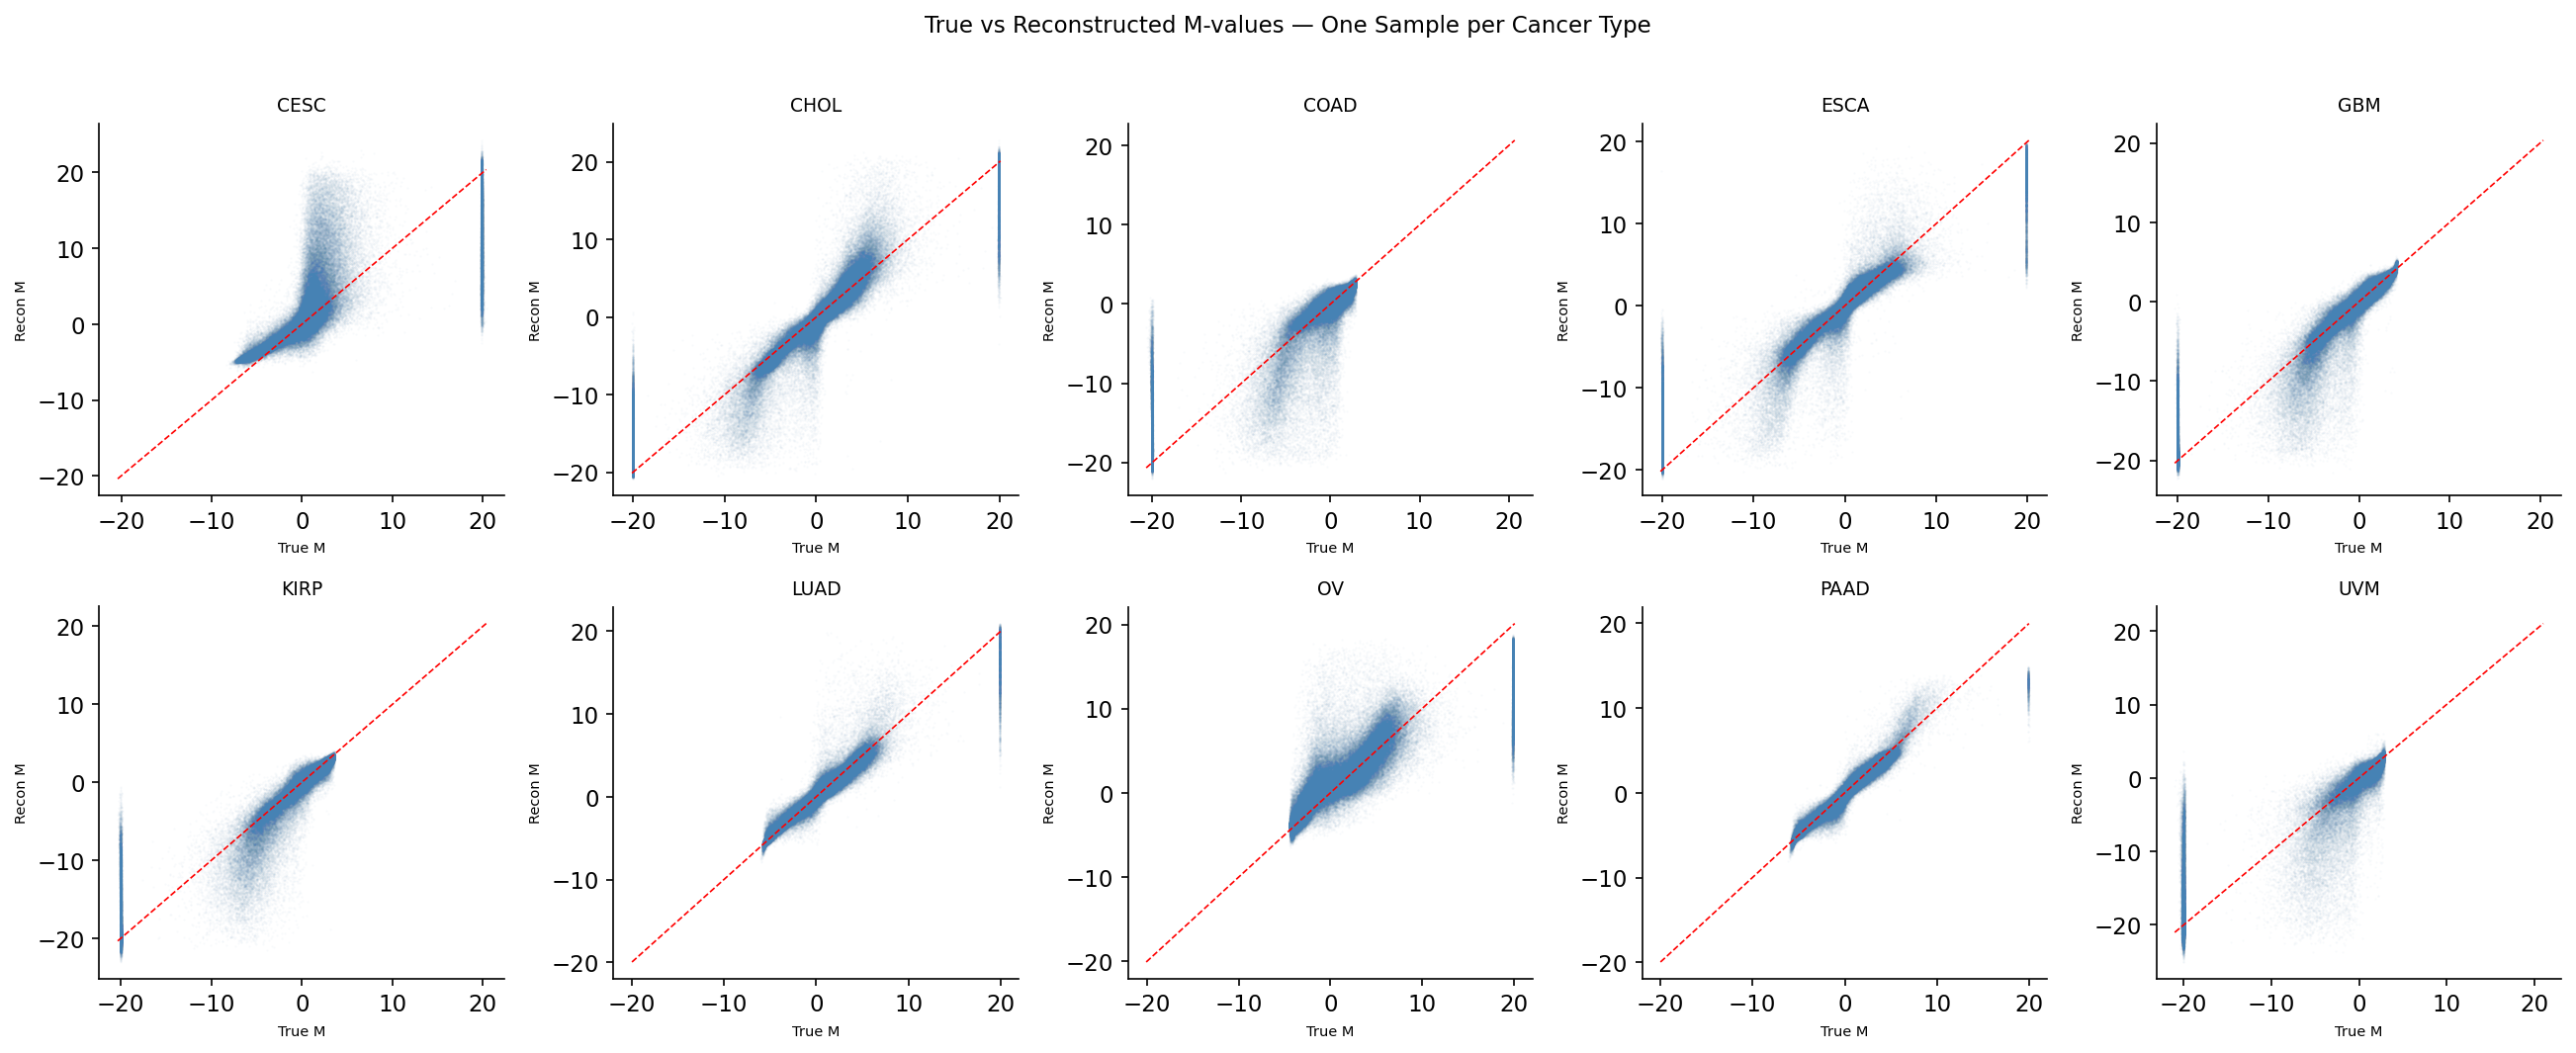

In [11]:
# Plot 3: True vs reconstructed M-values for one sample per cancer type
n_types  = meta_val["cancer_type"].nunique()
n_cols   = 5
n_rows   = int(np.ceil(n_types / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 3.5, n_rows * 3.5))
axes = axes.flatten()
for i, ct in enumerate(sorted(meta_val["cancer_type"].unique())):
    idx = meta_val[meta_val["cancer_type"] == ct].index[0]
    pos = meta_val.index.get_loc(idx)
    axes[i].scatter(X_val_np[pos], x_hat_val[pos],
                    alpha=0.04, s=1, color="steelblue", linewidths=0)
    lim = max(abs(X_val_np[pos].min()), abs(X_val_np[pos].max()))
    axes[i].plot([-lim, lim], [-lim, lim], "r--", linewidth=0.8)
    axes[i].set_title(ct, fontsize=9)
    axes[i].set_xlabel("True M", fontsize=7)
    axes[i].set_ylabel("Recon M", fontsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("True vs Reconstructed M-values — One Sample per Cancer Type",
             y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig("eval_reconstruction_per_type_scatter.png", bbox_inches="tight")
plt.show()

# 4. Latent Space Utilization (KL per Dimension)

In [12]:
kl_per_dim = (-0.5 * (
    1 + z_logvar_val - z_mu_val ** 2 - np.exp(z_logvar_val)
)).mean(axis=0)

n_active = (kl_per_dim > 0.1).sum()
print(f"\n--- Latent Utilisation ---")
print(f"  Active dimensions (KL > 0.1): {n_active} / {model.hparams.latent_dim}")
print(f"  Mean KL per dim:  {kl_per_dim.mean():.4f}")
print(f"  Max KL per dim:   {kl_per_dim.max():.4f}")


--- Latent Utilisation ---
  Active dimensions (KL > 0.1): 67 / 67
  Mean KL per dim:  1.4968
  Max KL per dim:   2.7426


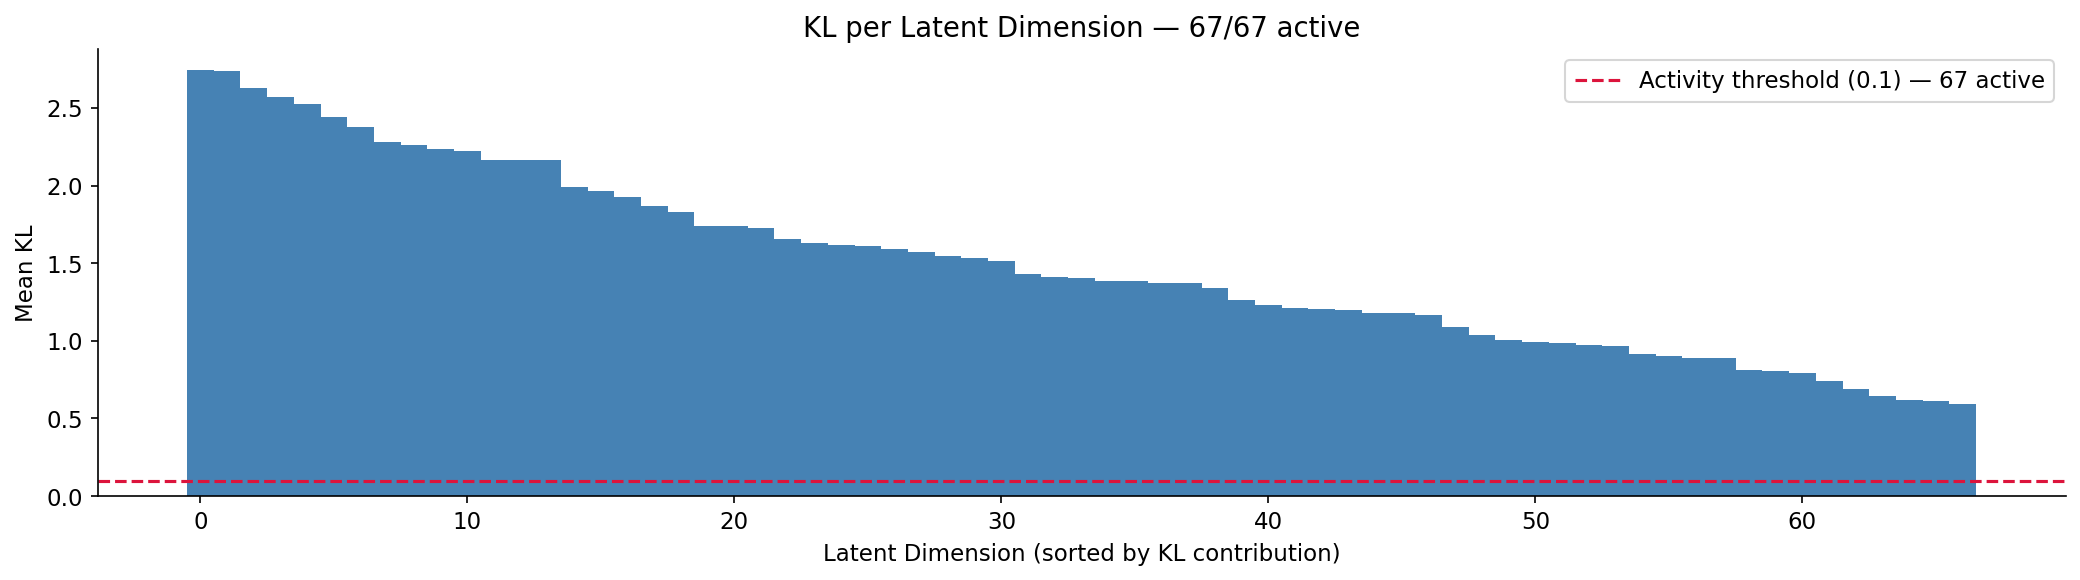

In [13]:
# Plot 1: KL per dim sorted bar
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(model.hparams.latent_dim), np.sort(kl_per_dim)[::-1],
       color="steelblue", width=1.0)
ax.axhline(0.1, color="crimson", linestyle="--",
           label=f"Activity threshold (0.1) — {n_active} active")
ax.set_xlabel("Latent Dimension (sorted by KL contribution)")
ax.set_ylabel("Mean KL")
ax.set_title(f"KL per Latent Dimension — {n_active}/{model.hparams.latent_dim} active")
ax.legend()
plt.tight_layout()
plt.savefig("eval_kl_per_dim.png")
plt.show()

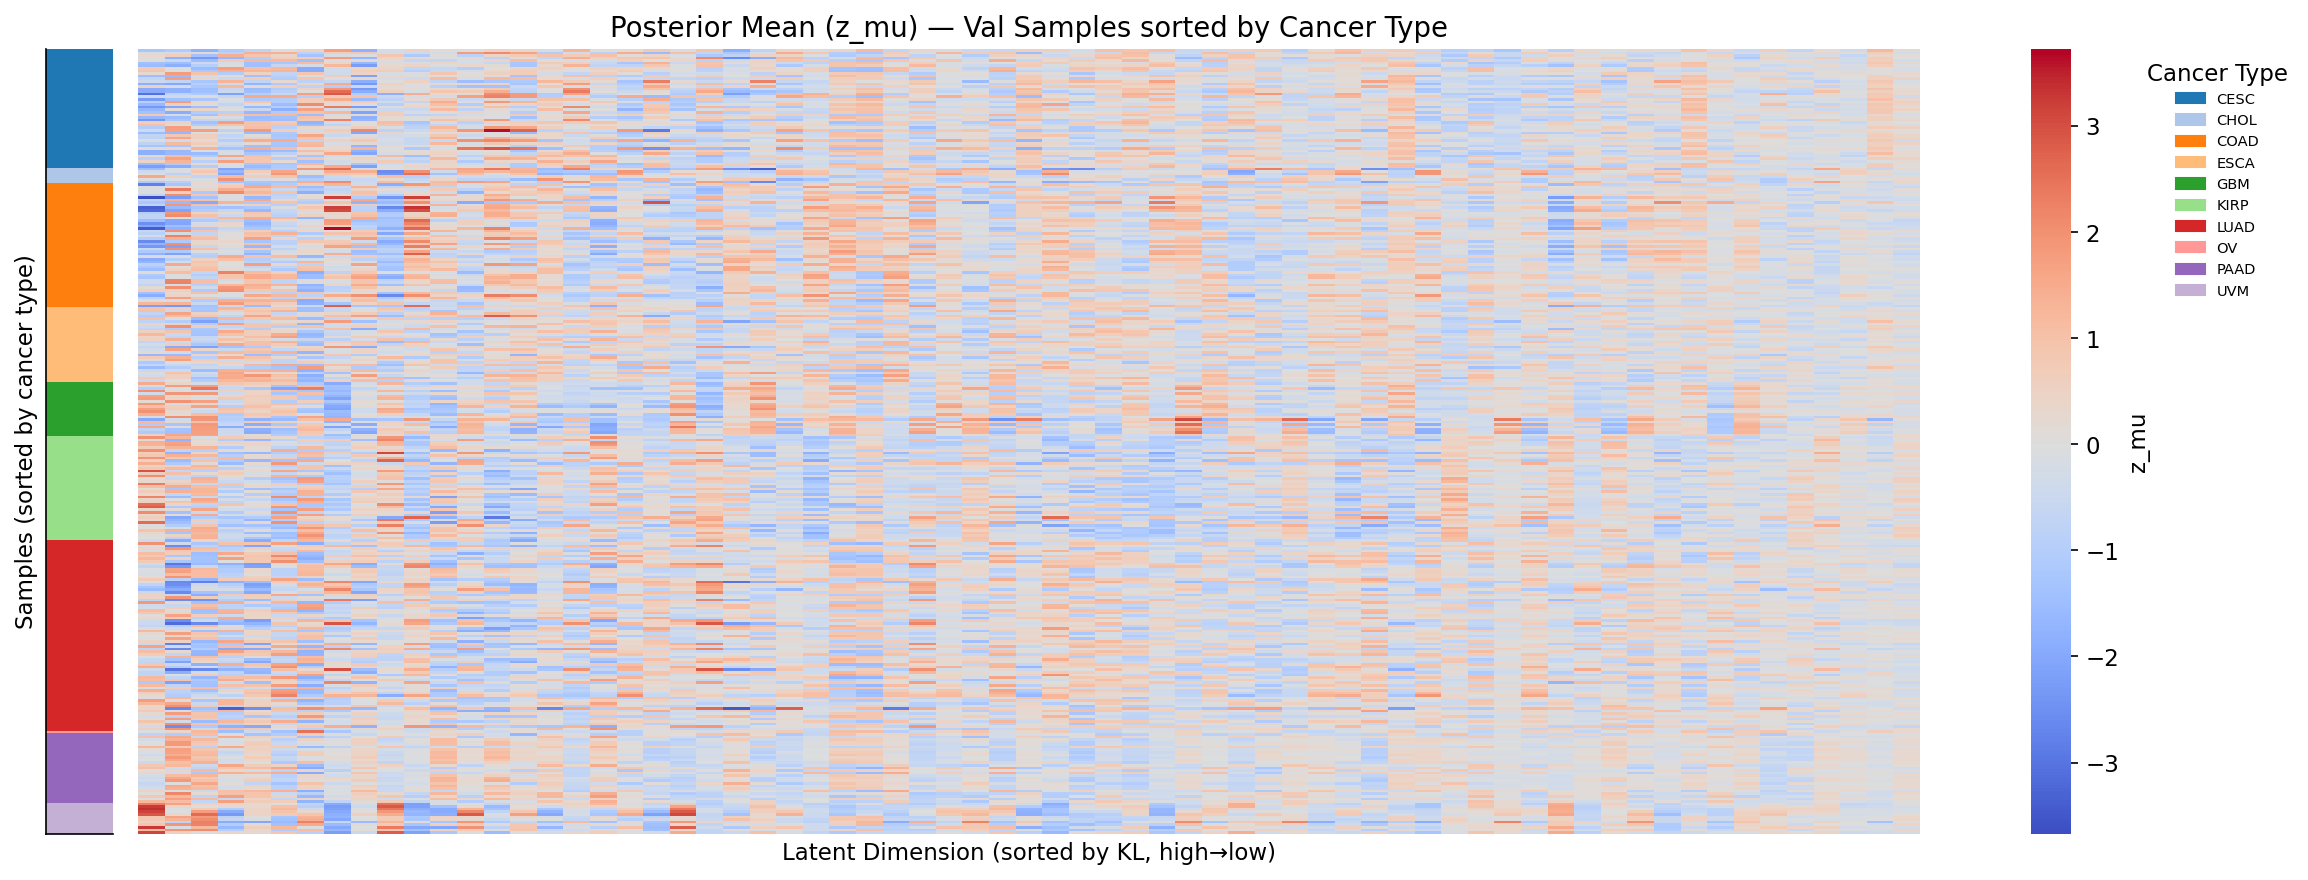

In [14]:
# Plot 2: z_mu heatmap — samples × dims, sorted by KL and by cancer type
sort_dim_idx     = np.argsort(kl_per_dim)[::-1]
sort_sample_idx  = meta_val.sort_values("cancer_type").index
sort_sample_pos  = [meta_val.index.get_loc(i) for i in sort_sample_idx]
sorted_z_mu      = z_mu_val[sort_sample_pos][:, sort_dim_idx]
cancer_order     = meta_val.loc[sort_sample_idx, "cancer_type"].values

# Build a colour bar for cancer type annotations
unique_types     = sorted(meta_val["cancer_type"].unique())
type_palette     = dict(zip(unique_types,
                            sns.color_palette("tab20", len(unique_types))))
row_colors       = pd.Series(cancer_order).map(type_palette)

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6),
    gridspec_kw={"width_ratios": [0.03, 1]}
)
# Cancer type colour bar
axes[0].imshow(
    np.array([[type_palette[t]] for t in cancer_order]),
    aspect="auto", interpolation="nearest"
)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_ylabel("Samples (sorted by cancer type)")

sns.heatmap(
    sorted_z_mu, cmap="coolwarm", center=0,
    xticklabels=False, yticklabels=False,
    ax=axes[1], cbar_kws={"label": "z_mu"}
)
axes[1].set_xlabel("Latent Dimension (sorted by KL, high→low)")
axes[1].set_title("Posterior Mean (z_mu) — Val Samples sorted by Cancer Type")

# Legend for cancer type colour bar
handles = [plt.Rectangle((0, 0), 1, 1, color=type_palette[t])
           for t in unique_types]
axes[1].legend(handles, unique_types, bbox_to_anchor=(1.12, 1),
               loc="upper left", fontsize=7, frameon=False,
               title="Cancer Type")
plt.tight_layout()
plt.savefig("eval_zmu_heatmap.png", bbox_inches="tight")
plt.show()

# 5. UMAP Visualizations

Note that visualizing by batch is omitted because it is across several projects and is way too granular

In [15]:
print("\nFitting UMAP on val embeddings...")
reducer = umap.UMAP(
    n_components = 2,
    n_neighbors  = 15,
    min_dist     = 0.1,
    metric       = "euclidean",
    random_state = 42,
)
z_umap_val  = reducer.fit_transform(z_mu_val)
z_umap_test = reducer.transform(z_mu_test)


Fitting UMAP on val embeddings...


/home/campbell/sophiali/miniforge3/envs/methylcdm-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [17]:
def umap_scatter(z_umap, labels, title, filename,
                 palette="tab20", s=25, alpha=0.8):
    unique_labels = np.unique(labels)
    cmap          = cm.get_cmap(palette, len(unique_labels))
    label_to_col  = {l: cmap(i) for i, l in enumerate(unique_labels)}

    fig, ax = plt.subplots(figsize=(9, 7))
    for label in unique_labels:
        mask = np.array(labels) == label
        ax.scatter(z_umap[mask, 0], z_umap[mask, 1],
                   c=[label_to_col[label]], label=label,
                   s=s, alpha=alpha, linewidths=0)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left",
              fontsize=8, markerscale=1.5, frameon=False)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

/tmp/ipykernel_1979615/360224131.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap          = cm.get_cmap(palette, len(unique_labels))


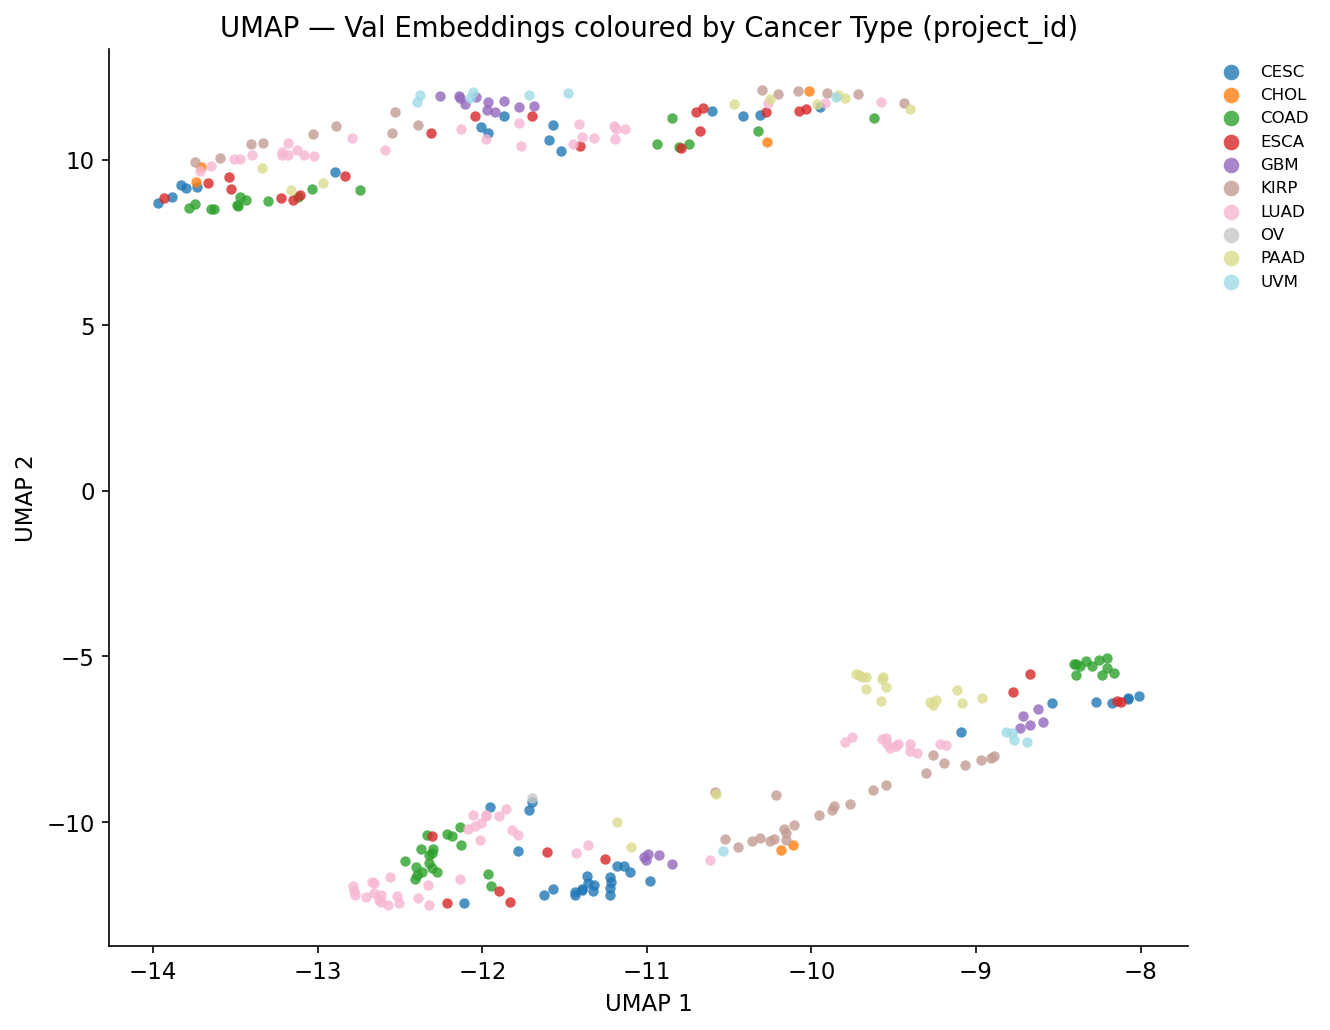

In [18]:
# 5a. Cancer type (project_id) — primary evaluation
umap_scatter(
    z_umap_val,
    meta_val["cancer_type"].values,
    title    = "UMAP — Val Embeddings coloured by Cancer Type (project_id)",
    filename = "eval_umap_cancer_type_val.png"
)

/tmp/ipykernel_1979615/360224131.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap          = cm.get_cmap(palette, len(unique_labels))


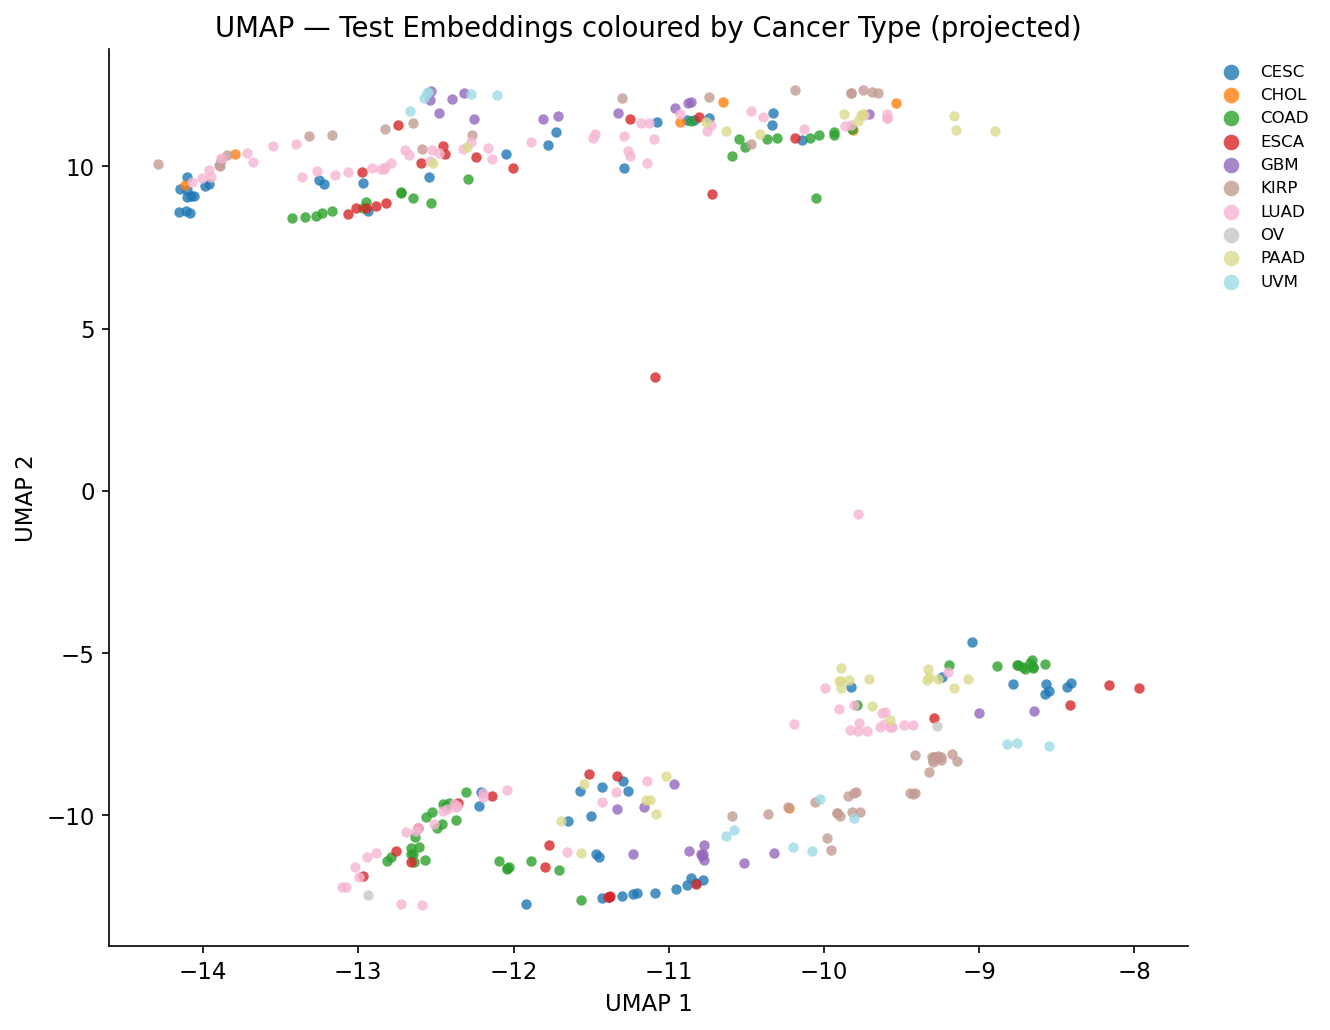

In [19]:
# 5b. Test set (projected using val UMAP fit)
umap_scatter(
    z_umap_test,
    meta_test["cancer_type"].values,
    title    = "UMAP — Test Embeddings coloured by Cancer Type (projected)",
    filename = "eval_umap_cancer_type_test.png"
)

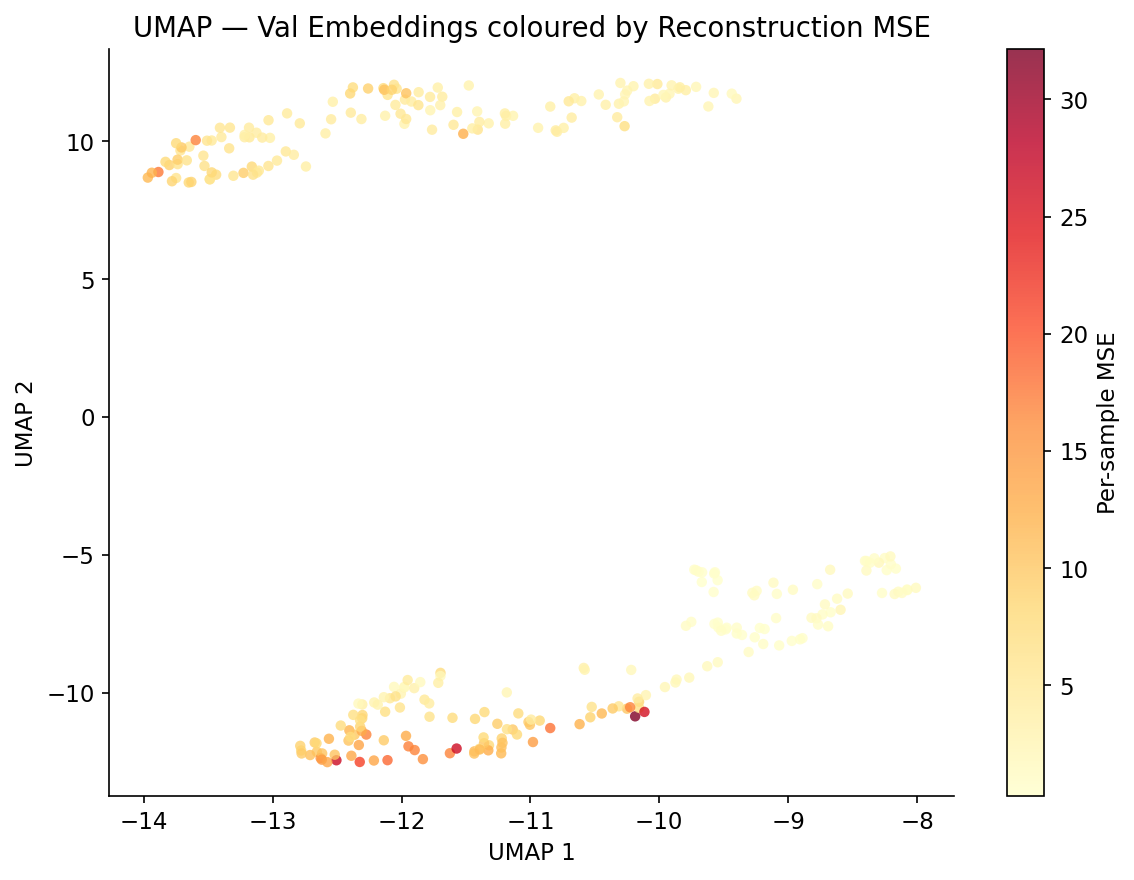

In [20]:
# 5c. Reconstruction error — spatially clustered high-MSE suggests
#     a cancer type is systematically poorly reconstructed
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(z_umap_val[:, 0], z_umap_val[:, 1],
                c=mse_val, cmap="YlOrRd", s=25, alpha=0.8, linewidths=0)
plt.colorbar(sc, ax=ax, label="Per-sample MSE")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP — Val Embeddings coloured by Reconstruction MSE")
plt.tight_layout()
plt.savefig("eval_umap_recon_error.png")
plt.show()

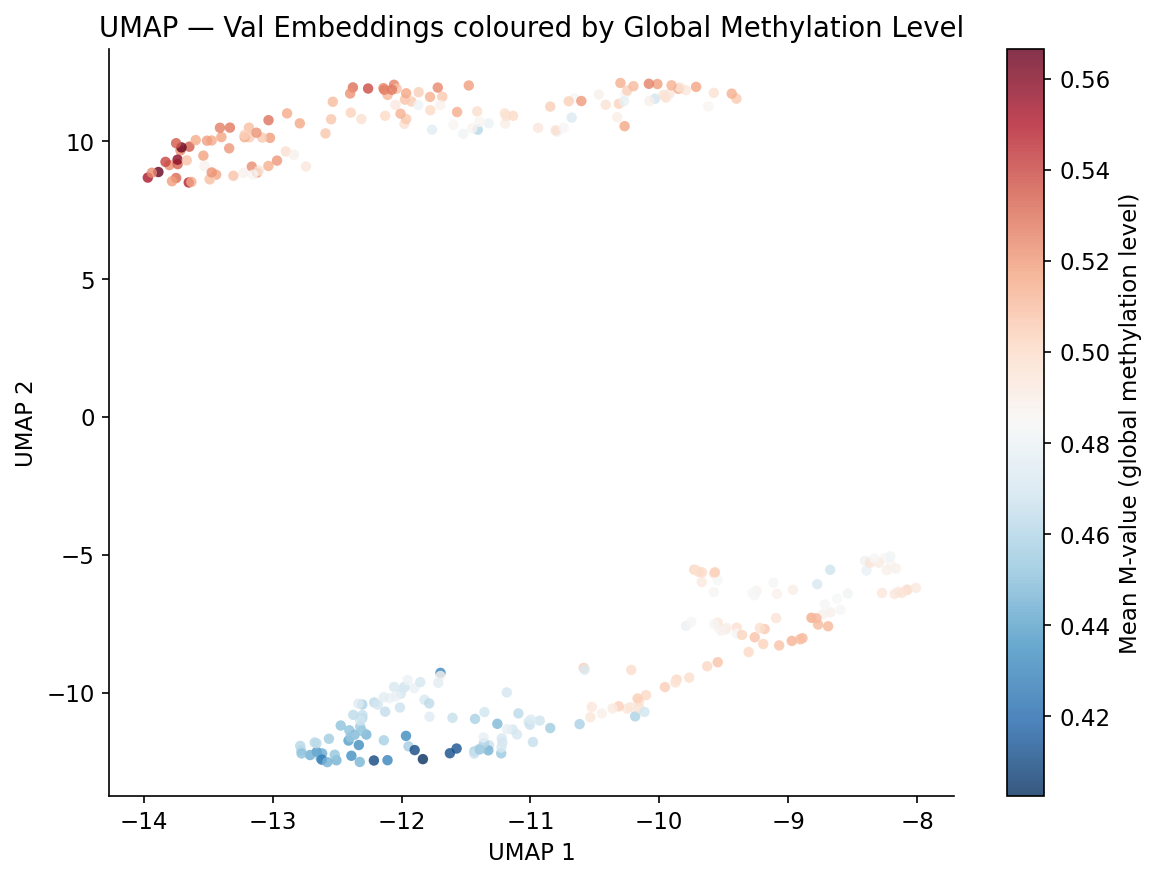

In [21]:
# 5d. Global methylation level (mean M-value per sample from .obs)
#     Should show a smooth gradient rather than discrete jumps — discrete
#     jumps suggest residual batch effects the model has encoded
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(z_umap_val[:, 0], z_umap_val[:, 1],
                c=meta_val["mean"].values, cmap="RdBu_r",
                s=25, alpha=0.8, linewidths=0)
plt.colorbar(sc, ax=ax, label="Mean M-value (global methylation level)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP — Val Embeddings coloured by Global Methylation Level")
plt.tight_layout()
plt.savefig("eval_umap_mean_mvalue.png")
plt.show()

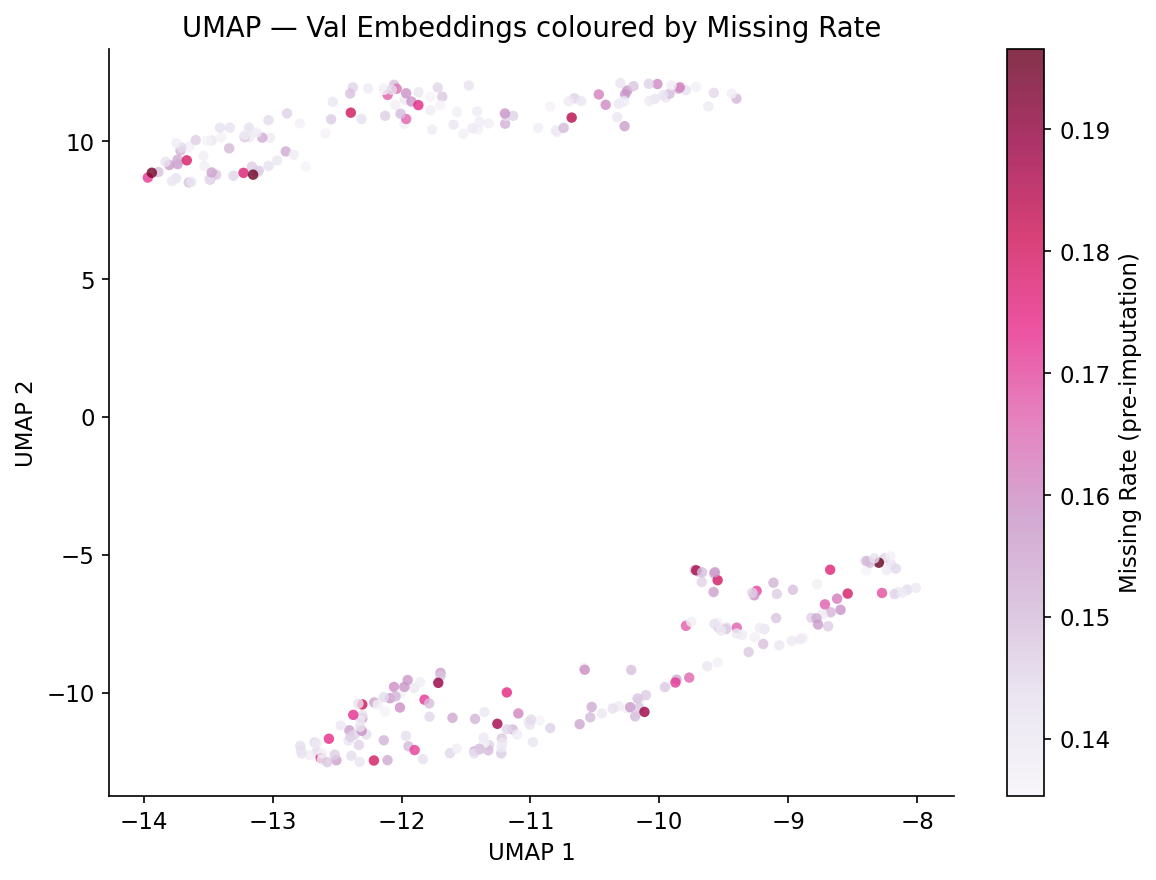

In [22]:
# 5e. Missing rate — high missing_rate samples should not cluster separately;
#     if they do, missingness is a confound in the latent space
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(z_umap_val[:, 0], z_umap_val[:, 1],
                c=meta_val["missing_rate"].values, cmap="PuRd",
                s=25, alpha=0.8, linewidths=0)
plt.colorbar(sc, ax=ax, label="Missing Rate (pre-imputation)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP — Val Embeddings coloured by Missing Rate")
plt.tight_layout()
plt.savefig("eval_umap_missing_rate.png")
plt.show()

/tmp/ipykernel_1979615/360224131.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap          = cm.get_cmap(palette, len(unique_labels))
/tmp/ipykernel_1979615/360224131.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


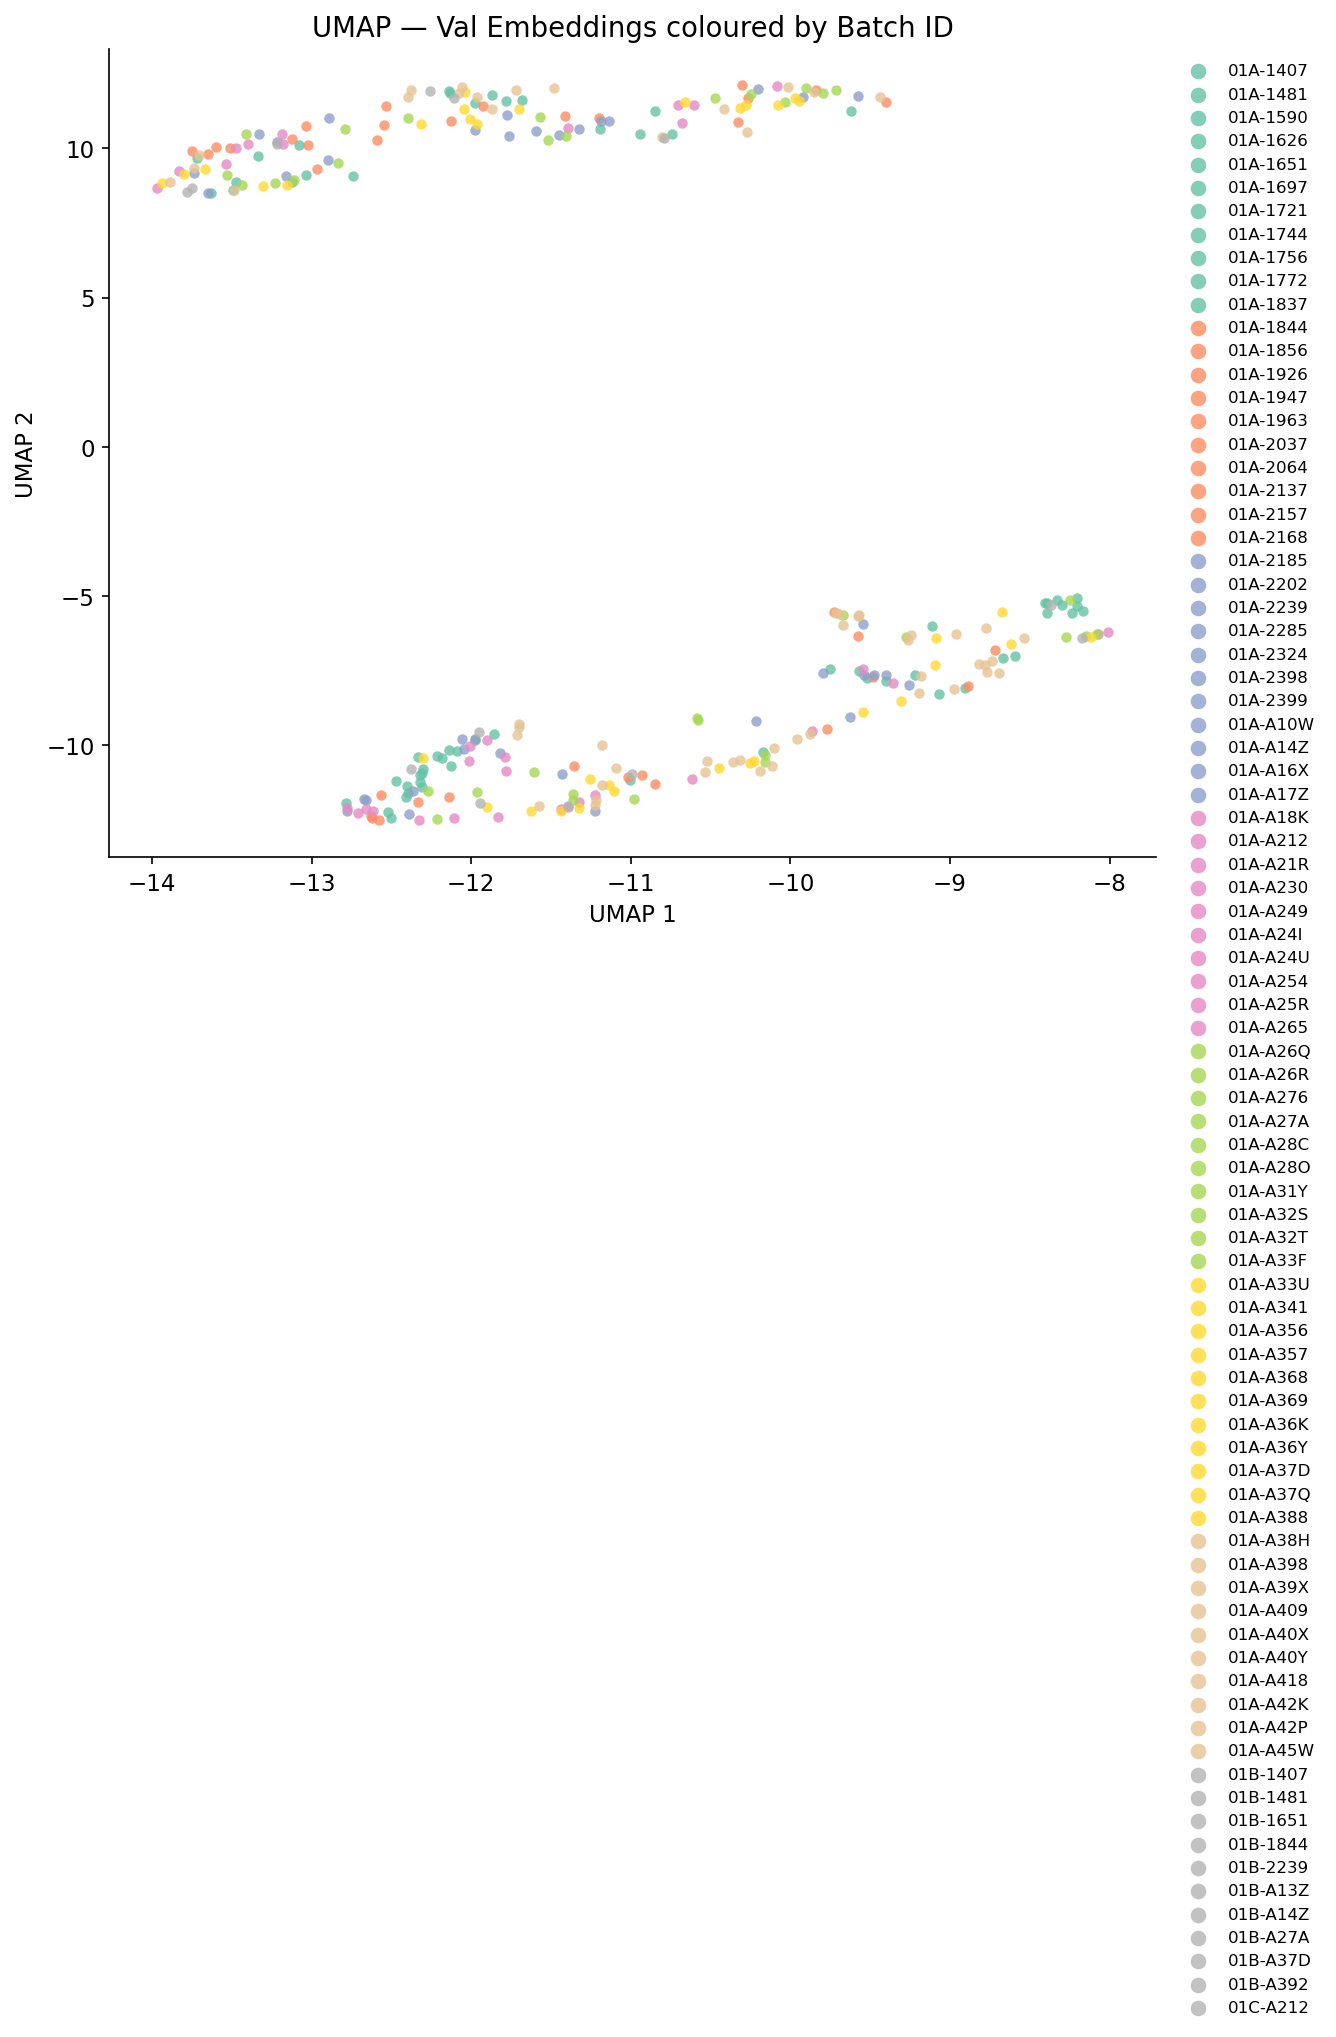

In [34]:
# ── eval_umap_batch_val.png ──────────────────────────────────────────
umap_scatter(
    z_umap_val,
    meta_val["batch_id"].values,
    title    = "UMAP — Val Embeddings coloured by Batch ID",
    filename = "eval_umap_batch_val.png",
    palette  = "Set2"
)

# 6. Latent Space Clustering (Silhouette, ARI)

In [23]:
le                = LabelEncoder()
cancer_labels_int = le.fit_transform(meta_val["cancer_type"].values)
n_cancer_types    = len(le.classes_)

# Silhouette on z_mu — not UMAP (UMAP distorts distances)
sil_cancer = silhouette_score(
    z_mu_val, cancer_labels_int, metric="euclidean",
    sample_size=min(500, len(z_mu_val))
)

# KMeans ARI against project_id labels
kmeans        = KMeans(n_clusters=n_cancer_types, random_state=42, n_init=10)
cluster_preds = kmeans.fit_predict(z_mu_val)
ari_cancer    = adjusted_rand_score(cancer_labels_int, cluster_preds)

# Also check silhouette against batch_id — should be LOW if batch correction
# was effective and the model hasn't re-encoded batch structure
batch_labels_int = LabelEncoder().fit_transform(meta_val["batch_id"].values)
sil_batch = silhouette_score(
    z_mu_val, batch_labels_int, metric="euclidean",
    sample_size=min(500, len(z_mu_val))
)

print(f"\n--- Clustering Quality (Val) ---")
print(f"  Cancer types:                          {n_cancer_types}")
print(f"  Silhouette (cancer type, z_mu):        {sil_cancer:.4f}  "
      f"[target: > 0.2]")
print(f"  KMeans ARI  (cancer type, k={n_cancer_types}):   "
      f"{ari_cancer:.4f}  [target: > 0.3]")
print(f"  Silhouette  (batch_id, z_mu):          {sil_batch:.4f}  "
      f"[target: < 0.1 — low is good]")


--- Clustering Quality (Val) ---
  Cancer types:                          10
  Silhouette (cancer type, z_mu):        -0.0768  [target: > 0.2]
  KMeans ARI  (cancer type, k=10):   0.0393  [target: > 0.3]
  Silhouette  (batch_id, z_mu):          -0.4442  [target: < 0.1 — low is good]


# 7. Batch Effect Check

Compares the mean z_mu vector per batch — if batch correction worked and the
model hasn't re-encoded batch, mean embeddings per batch should be close
together and not separable. Displayed as a clustermap of pairwise cosine
distances between per-batch centroids.

In [24]:
batch_ids       = meta_val["batch_id"].values
unique_batches  = np.unique(batch_ids)
batch_centroids = np.array([
    z_mu_val[batch_ids == b].mean(axis=0) for b in unique_batches
])

from sklearn.metrics.pairwise import cosine_distances
batch_dist = cosine_distances(batch_centroids)
batch_dist_df = pd.DataFrame(
    batch_dist,
    index=unique_batches,
    columns=unique_batches
)

In [25]:
fig, ax = plt.subplots(figsize=(max(6, len(unique_batches)),
                                max(5, len(unique_batches))))
sns.heatmap(batch_dist_df, cmap="Blues", annot=len(unique_batches) <= 10,
            fmt=".2f", ax=ax, cbar_kws={"label": "Cosine Distance"})
ax.set_title("Pairwise Cosine Distance Between Batch Centroids (z_mu)\n"
             "High distances = residual batch structure in latent space")
plt.tight_layout()
plt.savefig("eval_batch_centroid_distances.png", bbox_inches="tight")
plt.show()

In [26]:
print(f"\n--- Batch Effect Check ---")
print(f"  Mean pairwise batch centroid cosine distance: "
      f"{batch_dist[np.triu_indices_from(batch_dist, k=1)].mean():.4f}")
print(f"  (Values > 0.3 suggest residual batch structure in latent space)")


--- Batch Effect Check ---
  Mean pairwise batch centroid cosine distance: 0.9922
  (Values > 0.3 suggest residual batch structure in latent space)


# 8. Interpolation Sanity Check

Interpolate between two samples from different cancer types.
Smooth intermediate distributions confirm a well-structured latent space.
Pick the pair with the largest Euclidean distance in z_mu — tests the
hardest interpolation case rather than two nearby samples.

In [27]:
dist_matrix  = np.linalg.norm(
    z_mu_val[:, None, :] - z_mu_val[None, :, :], axis=-1
)
idx_a, idx_b = np.unravel_index(dist_matrix.argmax(), dist_matrix.shape)
ct_a = meta_val["cancer_type"].iloc[idx_a]
ct_b = meta_val["cancer_type"].iloc[idx_b]
print(f"\nInterpolating between sample {idx_a} ({ct_a}) "
      f"and sample {idx_b} ({ct_b})")


Interpolating between sample 29 (UVM) and sample 142 (COAD)


In [28]:
z_a      = torch.tensor(z_mu_val[idx_a], dtype=torch.float32).unsqueeze(0).to(DEVICE)
z_b      = torch.tensor(z_mu_val[idx_b], dtype=torch.float32).unsqueeze(0).to(DEVICE)
n_steps  = 10
alphas   = np.linspace(0, 1, n_steps)
interpolated = []
with torch.no_grad():
    for alpha in alphas:
        z_interp = (1 - alpha) * z_a + alpha * z_b
        interpolated.append(model.decode(z_interp).cpu().numpy().squeeze())
interpolated = np.array(interpolated)

/tmp/ipykernel_1979615/2911432824.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_interp = cm.get_cmap("coolwarm", n_steps)


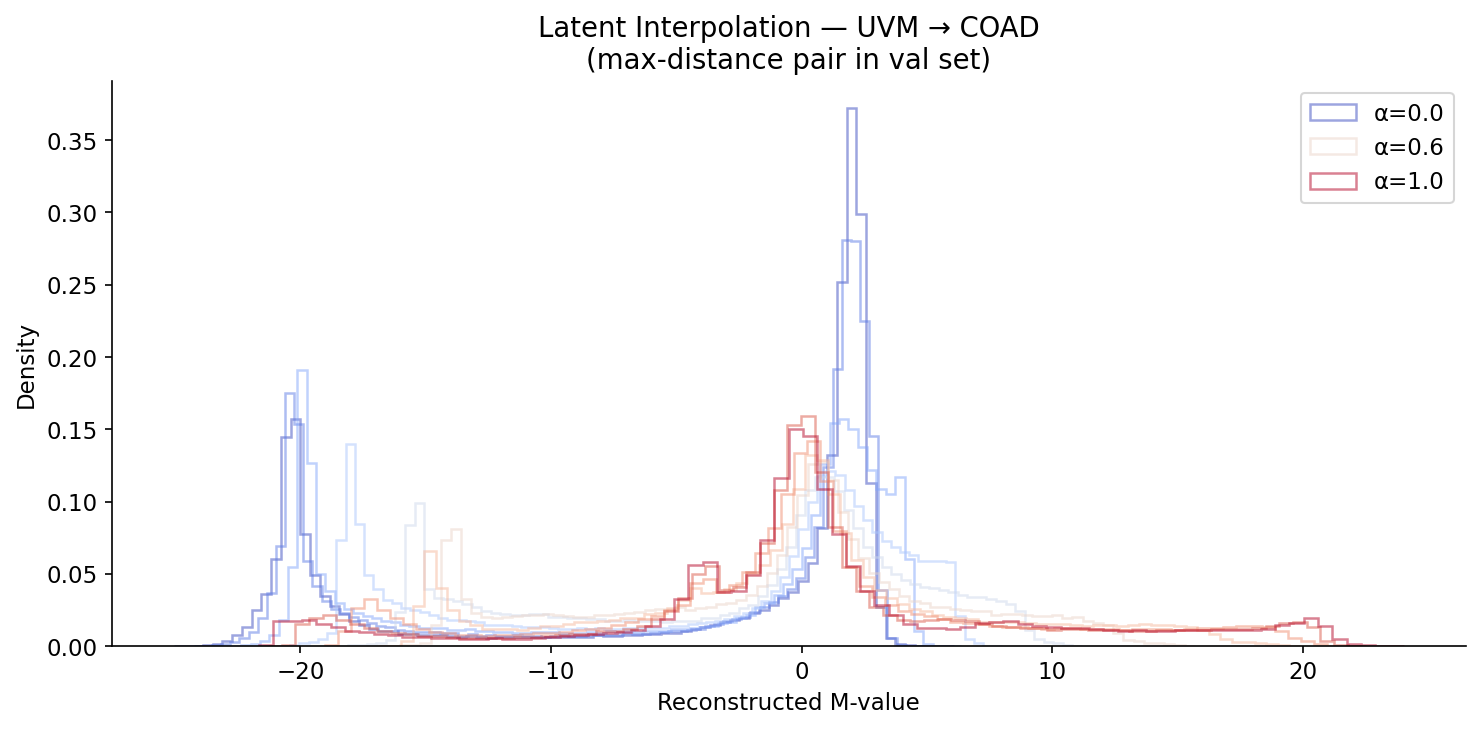

In [29]:
# Plot: M-value distribution at each interpolation step
fig, ax = plt.subplots(figsize=(10, 5))
cmap_interp = cm.get_cmap("coolwarm", n_steps)
for i, (x_interp, alpha) in enumerate(zip(interpolated, alphas)):
    ax.hist(x_interp, bins=80, alpha=0.5, color=cmap_interp(i),
            density=True, histtype="step", linewidth=1.2,
            label=f"α={alpha:.1f}" if i in [0, n_steps // 2, n_steps - 1] else "")
ax.set_xlabel("Reconstructed M-value")
ax.set_ylabel("Density")
ax.set_title(f"Latent Interpolation — {ct_a} → {ct_b}\n"
             f"(max-distance pair in val set)")
ax.legend()
plt.tight_layout()
plt.savefig("eval_interpolation.png")
plt.show()

In [30]:
adj_r = [
    np.corrcoef(interpolated[i], interpolated[i + 1])[0, 1]
    for i in range(n_steps - 1)
]
print(f"  Adjacent step Pearson r — min: {min(adj_r):.4f}  "
      f"mean: {np.mean(adj_r):.4f}  [target: > 0.9]")

  Adjacent step Pearson r — min: 0.9832  mean: 0.9907  [target: > 0.9]


# 9. Posterior Collapse Diagnostic

In [31]:
z_mu_var_per_dim     = z_mu_val.var(axis=0)
z_logvar_mean_per_dim = z_logvar_val.mean(axis=0)
n_collapsed          = (z_mu_var_per_dim < 1e-3).sum()

print(f"\n--- Posterior Collapse Diagnostic ---")
print(f"  Collapsed dims (z_mu var < 1e-3): "
      f"{n_collapsed} / {model.hparams.latent_dim}")
print(f"  Mean z_logvar across dims: {z_logvar_mean_per_dim.mean():.4f}  "
      f"(near 0 everywhere = collapse)")


--- Posterior Collapse Diagnostic ---
  Collapsed dims (z_mu var < 1e-3): 0 / 67
  Mean z_logvar across dims: -3.3149  (near 0 everywhere = collapse)


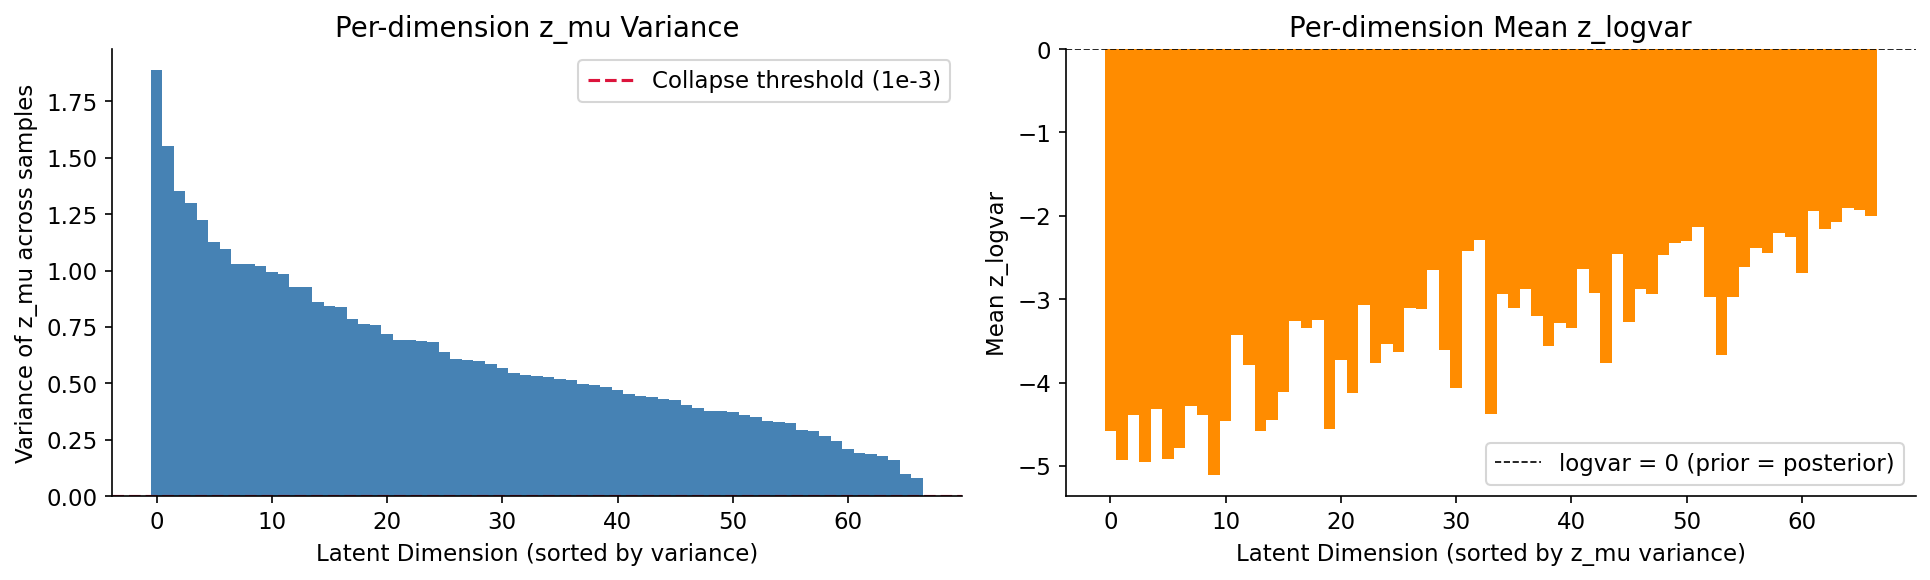

In [32]:
sort_var_idx = np.argsort(z_mu_var_per_dim)[::-1]
fig, axes    = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(model.hparams.latent_dim),
            z_mu_var_per_dim[sort_var_idx],
            color="steelblue", width=1.0)
axes[0].axhline(1e-3, color="crimson", linestyle="--",
                label="Collapse threshold (1e-3)")
axes[0].set_xlabel("Latent Dimension (sorted by variance)")
axes[0].set_ylabel("Variance of z_mu across samples")
axes[0].set_title("Per-dimension z_mu Variance")
axes[0].legend()

axes[1].bar(range(model.hparams.latent_dim),
            z_logvar_mean_per_dim[sort_var_idx],
            color="darkorange", width=1.0)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8,
                label="logvar = 0 (prior = posterior)")
axes[1].set_xlabel("Latent Dimension (sorted by z_mu variance)")
axes[1].set_ylabel("Mean z_logvar")
axes[1].set_title("Per-dimension Mean z_logvar")
axes[1].legend()

plt.tight_layout()
plt.savefig("eval_collapse_diagnostic.png")
plt.show()

# 10. Evaluation Summary

In [33]:
print("\n" + "=" * 50)
print("        BETAVAE EVALUATION SUMMARY")
print("=" * 50)
print(f"  Checkpoint:   {CHECKPOINT_PATH}")
print(f"  Latent dim:   {model.hparams.latent_dim}")
print(f"  Beta (max):   {model.hparams.beta}")
print("-" * 50)
print("  RECONSTRUCTION")
print(f"    Pearson r — val  (mean): {r_val.mean():.4f}   [target: > 0.95]")
print(f"    Pearson r — test (mean): {r_test.mean():.4f}   [target: > 0.95]")
print("-" * 50)
print("  LATENT SPACE")
print(f"    Active dims (KL > 0.1):  {n_active} / {model.hparams.latent_dim}"
      f"   [target: > 50%]")
print(f"    Collapsed dims:          {n_collapsed} / {model.hparams.latent_dim}"
      f"   [target: < 10%]")
print("-" * 50)
print("  BIOLOGICAL STRUCTURE")
print(f"    Silhouette (cancer type): {sil_cancer:.4f}   [target: > 0.2]")
print(f"    KMeans ARI (cancer type): {ari_cancer:.4f}   [target: > 0.3]")
print("-" * 50)
print("  CONFOUND CHECKS")
print(f"    Silhouette (batch_id):    {sil_batch:.4f}   [target: < 0.1]")
print(f"    Interpolation smoothness: {min(adj_r):.4f}   [target: > 0.9]")
print("=" * 50)


        BETAVAE EVALUATION SUMMARY
  Checkpoint:   /ddn_exa/campbell/sli/methylcdm-project/models/beta_vae/betaVAE_sweep_20260302_214939/trial_18/best-epoch=199-val_loss=5.7425.ckpt
  Latent dim:   67
  Beta (max):   0.0016728426260081176
--------------------------------------------------
  RECONSTRUCTION
    Pearson r — val  (mean): 0.9425   [target: > 0.95]
    Pearson r — test (mean): 0.9448   [target: > 0.95]
--------------------------------------------------
  LATENT SPACE
    Active dims (KL > 0.1):  67 / 67   [target: > 50%]
    Collapsed dims:          0 / 67   [target: < 10%]
--------------------------------------------------
  BIOLOGICAL STRUCTURE
    Silhouette (cancer type): -0.0768   [target: > 0.2]
    KMeans ARI (cancer type): 0.0393   [target: > 0.3]
--------------------------------------------------
  CONFOUND CHECKS
    Silhouette (batch_id):    -0.4442   [target: < 0.1]
    Interpolation smoothness: 0.9832   [target: > 0.9]
